In [1]:
from Distribution import Distribution
from queue import PriorityQueue
from matplotlib import pyplot as plt
import numpy as np
from scipy import stats

from joblib import Parallel, delayed
import multiprocessing
num_cores = multiprocessing.cpu_count()
from tqdm import tqdm

In [2]:
class FES:
    
    def __init__(self):
        self.q = PriorityQueue()

    def add(self, event):
        self.q.put(event)
    
    def next(self):
        return self.q.get()

    def isEmpty(self):
        return self.q.empty()
    
class Event:

    CUST_ARRIVAL = 0
    CUST_DEPARTURE = 1
    CUST_TO_TREATMENT = 2
    CUST_FROM_TREATMENT = 3
    EVENT_TYPE = ["CUST_ARRIVAL", "CUST_DEPARTURE", "CUST_TO_TREATMENT", "CUST_FROM_TREATMENT"]

    def __init__(self, eventType, time):
        self.eventType = eventType
        self.time = time

    def __lt__(self,other):
        return self.time < other.time

    def getType(self):
        return self.type

In [108]:
def sim(β, γ, T, debug=False):
    # Distribution is a class written by Marko Boon for
    # the bachelor course Stochastic Simulation. It simply
    # generates a large number of samples at once which saves
    # on running time compared to generating one sample at a time.
    arr_dist = Distribution(stats.expon(scale=1/λ))
    service_dist = Distribution(stats.expon(scale=1/μ))
    treatment_bern = Distribution(stats.bernoulli(p=p))
    treatment_dist = Distribution(stats.expon(scale=1/ν))  

    c = int(np.ceil(λ/((1-p)*μ) + β*np.sqrt(λ/((1-p)*μ))))
    n = int(np.ceil(λ/((1-p)*μ*r) + γ*np.sqrt(λ/((1-p)*μ*r))))
    t = 0
    Qs = n
    Qc = 0
    Qt = 0
    EventQueue = FES()
    Qlengths = [] # keeps track of queue lengths over time

    # variables for computing block probability
    tot_customers = 0
    blocked_customers = 0

    # variables for computing waiting probability and average waiting time
    # by "waiting" we mean anytime a customer tries to enter Qc and all
    # employees are busy. The same customer might have to enter Qc multiple
    # times, so the waiting probability is computed over all entries to Qc,
    # not merely over all customers.
    Qc_entries_waiting = 0
    Qc_entries_tot = 0
    waiting_starttimes = []
    waiting_endtimes = []

    e0 = Event(Event.CUST_ARRIVAL, time=arr_dist.rvs())
    EventQueue.add(e0)

    while t < T:
        Qlengths.append([t, Qs, Qc, Qt])
        nextE = EventQueue.next()
        t = nextE.time

        if debug == True:
            print(f"Qs={Qs}/{n}, Qc={Qc}/{c}, Qt={Qt}")
            print(f"Time: {t} - {Event.EVENT_TYPE[nextE.eventType]}")

        # 1. HANDLE CUST_ARRIVAL EVENT
        if nextE.eventType == Event.CUST_ARRIVAL:
            tot_customers += 1

            # plan next customer arrival
            e = Event(Event.CUST_ARRIVAL, time=t+arr_dist.rvs())
            EventQueue.add(e)

            # if a seat is not available, the customer leaves so we do nothing
            if Qs == 0:
                blocked_customers += 1
                if debug == True:
                    print("Customer blocked")

            # if a seat is available, the seat moves from Qs to Qc
            if Qs > 0:
                Qs -= 1
                Qc += 1
                Qc_entries_tot += 1

                # if an employee is not available to help, the customer must wait
                if Qc > c:
                    Qc_entries_waiting += 1
                    waiting_starttimes.append(t)
                    if debug == True:
                        print("Customer has to wait")

                # if an employee is available to help, plan the end of service
                if Qc <= c:
                    # at this stage we must also decide whether the customer needs extra treatment
                    treatment = treatment_bern.rvs()
                    if treatment == True:
                        e = Event(Event.CUST_TO_TREATMENT, time=t+service_dist.rvs())
                        EventQueue.add(e)
                    if treatment == False:
                        e = Event(Event.CUST_DEPARTURE, time=t+service_dist.rvs())
                        EventQueue.add(e)
    

        # 2. HANDLE CUST_DEPARTURE EVENT
        if nextE.eventType == Event.CUST_DEPARTURE:
            # a seat moves from Qc back to Qs
            Qc -= 1
            Qs += 1

            # check if another seat is waiting to be served by an employee
            if Qc >= c:
                # note the end of the waiting time
                waiting_endtimes.append(t)
                if debug == True:
                    print("Customer finishes waiting for service")

                # start serving that customer and plan the end of service
                treatment = treatment_bern.rvs()
                if treatment == True:
                    e = Event(Event.CUST_TO_TREATMENT, time=t+service_dist.rvs())
                    EventQueue.add(e)
                if treatment == False:
                    e = Event(Event.CUST_DEPARTURE, time=t+service_dist.rvs())
                    EventQueue.add(e)
    

        # 3. HANDLE CUST_TO_TREATMENT EVENT
        if nextE.eventType == Event.CUST_TO_TREATMENT:
            # a seat moves from Qc to Qt
            Qc -= 1
            Qt += 1

            # plan the end of the treatment
            e = Event(Event.CUST_FROM_TREATMENT, time=t+treatment_dist.rvs())
            EventQueue.add(e)

            # check if another seat is waiting to be served by an employee
            if Qc >= c:
                # note the end of the waiting time
                waiting_endtimes.append(t)
                if debug == True:
                    print("Customer finishes waiting for service")

                # start serving that customer and plan the end of service:
                treatment = treatment_bern.rvs()
                if treatment == True:
                    e = Event(Event.CUST_TO_TREATMENT, time=t+service_dist.rvs())
                    EventQueue.add(e)
                if treatment == False:
                    e = Event(Event.CUST_DEPARTURE, time=t+service_dist.rvs())
                    EventQueue.add(e)


        # 4. HANDLE CUST_FROM_TREATMENT EVENT
        if nextE.eventType == Event.CUST_FROM_TREATMENT:
            # a seat moves from Qt back to Qc
            Qt -= 1
            Qc += 1
            Qc_entries_tot += 1

            # if an employee is not available to help, the customer must wait
            if Qc > c:
                Qc_entries_waiting += 1
                waiting_starttimes.append(t)
                if debug == True:
                    print("Customer has to wait")

            # if an employee is available to help, plan the end of service
            if Qc <= c:
                # at this stage we must also decide whether the customer needs extra treatment
                treatment = treatment_bern.rvs()
                if treatment == True:
                    e = Event(Event.CUST_TO_TREATMENT, time=t+service_dist.rvs())
                    EventQueue.add(e)
                if treatment == False:
                    e = Event(Event.CUST_DEPARTURE, time=t+service_dist.rvs())
                    EventQueue.add(e)
                    

    # compute block probability
    block_prob = blocked_customers / tot_customers

    # compute waiting probability
    waiting_prob = Qc_entries_waiting / Qc_entries_tot

    # compute average waiting time
    # in the case that at t=T, some customers are still waiting, the list
    # of waiting_starttimes will be longer than the list of waiting_endtimes
    # in this case we simply truncate the waiting_starttimes to the length of 
    # waiting_endtimes
    if waiting_endtimes != []:
        avg_waiting_time = np.mean(waiting_endtimes) - np.mean(waiting_starttimes[:len(waiting_endtimes)])
    else:
        avg_waiting_time = 0

    # compute average queue lengths over time
    timespans = np.diff([q[0] for q in Qlengths])
    avg_Qs = np.sum(timespans*[q[1] for q in Qlengths[:-1]])/T
    avg_Qc = np.sum(timespans*[q[2] for q in Qlengths[:-1]])/T
    avg_Qt = np.sum(timespans*[q[3] for q in Qlengths[:-1]])/T

    return avg_Qs, avg_Qc, avg_Qt, block_prob, waiting_prob, avg_waiting_time

In [ ]:
# define parameters
λ=60
μ=4
ν=4
p=1/4
r = ν/(ν+p*μ)

# define ranges for β and γ
β_min = -2
β_max = 2
β_stepsize = 0.1
γ_min = -2
γ_max = 2
γ_stepsize = 0.1
β_range = np.arange(β_min,β_max+β_stepsize,β_stepsize)
γ_range = np.arange(γ_min,γ_max+γ_stepsize,γ_stepsize)

# initialize 2D arrays for simulation results over the defined ranges for β and γ
avg_Qs = np.zeros((int((β_max-β_min)/β_stepsize)+1, int((γ_max-γ_min)/γ_stepsize)+1))
avg_Qc = np.zeros((int((β_max-β_min)/β_stepsize)+1, int((γ_max-γ_min)/γ_stepsize)+1))
avg_Qt = np.zeros((int((β_max-β_min)/β_stepsize)+1, int((γ_max-γ_min)/γ_stepsize)+1))

block_prob = np.zeros((int((β_max-β_min)/β_stepsize)+1, int((γ_max-γ_min)/γ_stepsize)+1))
waiting_prob = np.zeros((int((β_max-β_min)/β_stepsize)+1, int((γ_max-γ_min)/γ_stepsize)+1))
avg_waiting_time = np.zeros((int((β_max-β_min)/β_stepsize)+1, int((γ_max-γ_min)/γ_stepsize)+1))


N = 160 # number of simulations to perform per selection of values (β,γ)
T = 10 # total time per simulation

for β in tqdm(β_range):
    for γ in tqdm(γ_range, leave=False):
        sim_results = Parallel(n_jobs = num_cores) (delayed(sim)(β, γ, T=T, debug=False) for _ in range(N))

        avg_Qs[int((β-β_min)/β_stepsize),int((γ-γ_min)/γ_stepsize)] = np.mean([res[0] for res in sim_results])
        avg_Qc[int((β-β_min)/β_stepsize),int((γ-γ_min)/γ_stepsize)] = np.mean([res[1] for res in sim_results])
        avg_Qt[int((β-β_min)/β_stepsize),int((γ-γ_min)/γ_stepsize)] = np.mean([res[2] for res in sim_results])
        
        block_prob[int((β-β_min)/β_stepsize),int((γ-γ_min)/γ_stepsize)] = np.mean([res[3] for res in sim_results])
        waiting_prob[int((β-β_min)/β_stepsize),int((γ-γ_min)/γ_stepsize)] = np.mean([res[4] for res in sim_results])
        avg_waiting_time[int((β-β_min)/β_stepsize),int((γ-γ_min)/γ_stepsize)] = np.mean([res[5] for res in sim_results])

100%|██████████| 41/41 [07:14<00:00, 10.61s/it]


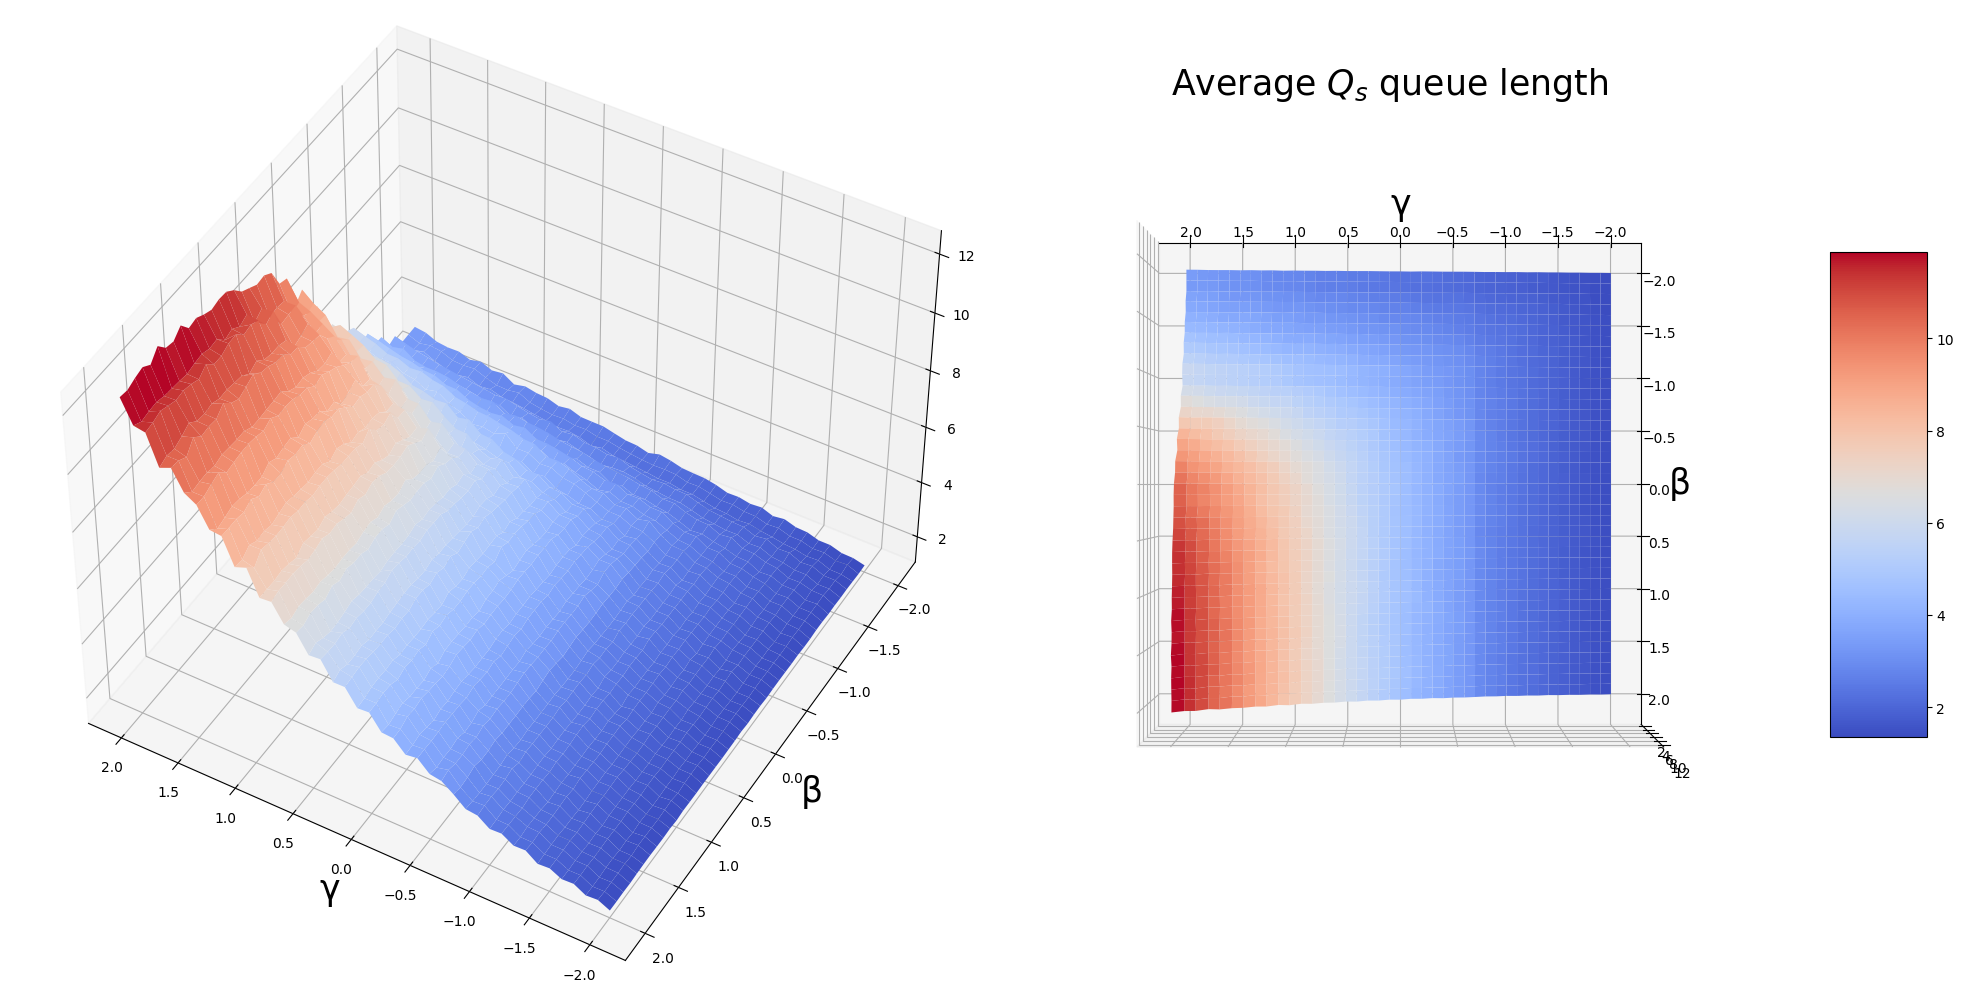

In [104]:
fig, ax = plt.subplots(1, 2, subplot_kw={"projection": "3d"})
plt.title("Average $Q_s$ queue length",fontsize=25)
fig.set_figheight(10)
fig.set_figwidth(20)
X, Y = np.meshgrid(γ_range, β_range)
ax[0].view_init(elev=45, azim=120)
ax[1].view_init(elev=90, azim=90)
ax[0].set_xlabel("γ", fontsize=25)
ax[0].set_ylabel("β", fontsize=25)
ax[1].set_xlabel("γ", fontsize=25)
ax[1].set_ylabel("β", fontsize=25)
surf = ax[0].plot_surface(X, Y, avg_Qs, cmap=plt.cm.coolwarm)
surf = ax[1].plot_surface(X, Y, avg_Qs, cmap=plt.cm.coolwarm)
fig.colorbar(surf, shrink=0.5, aspect=5)
fig.tight_layout()
plt.show()

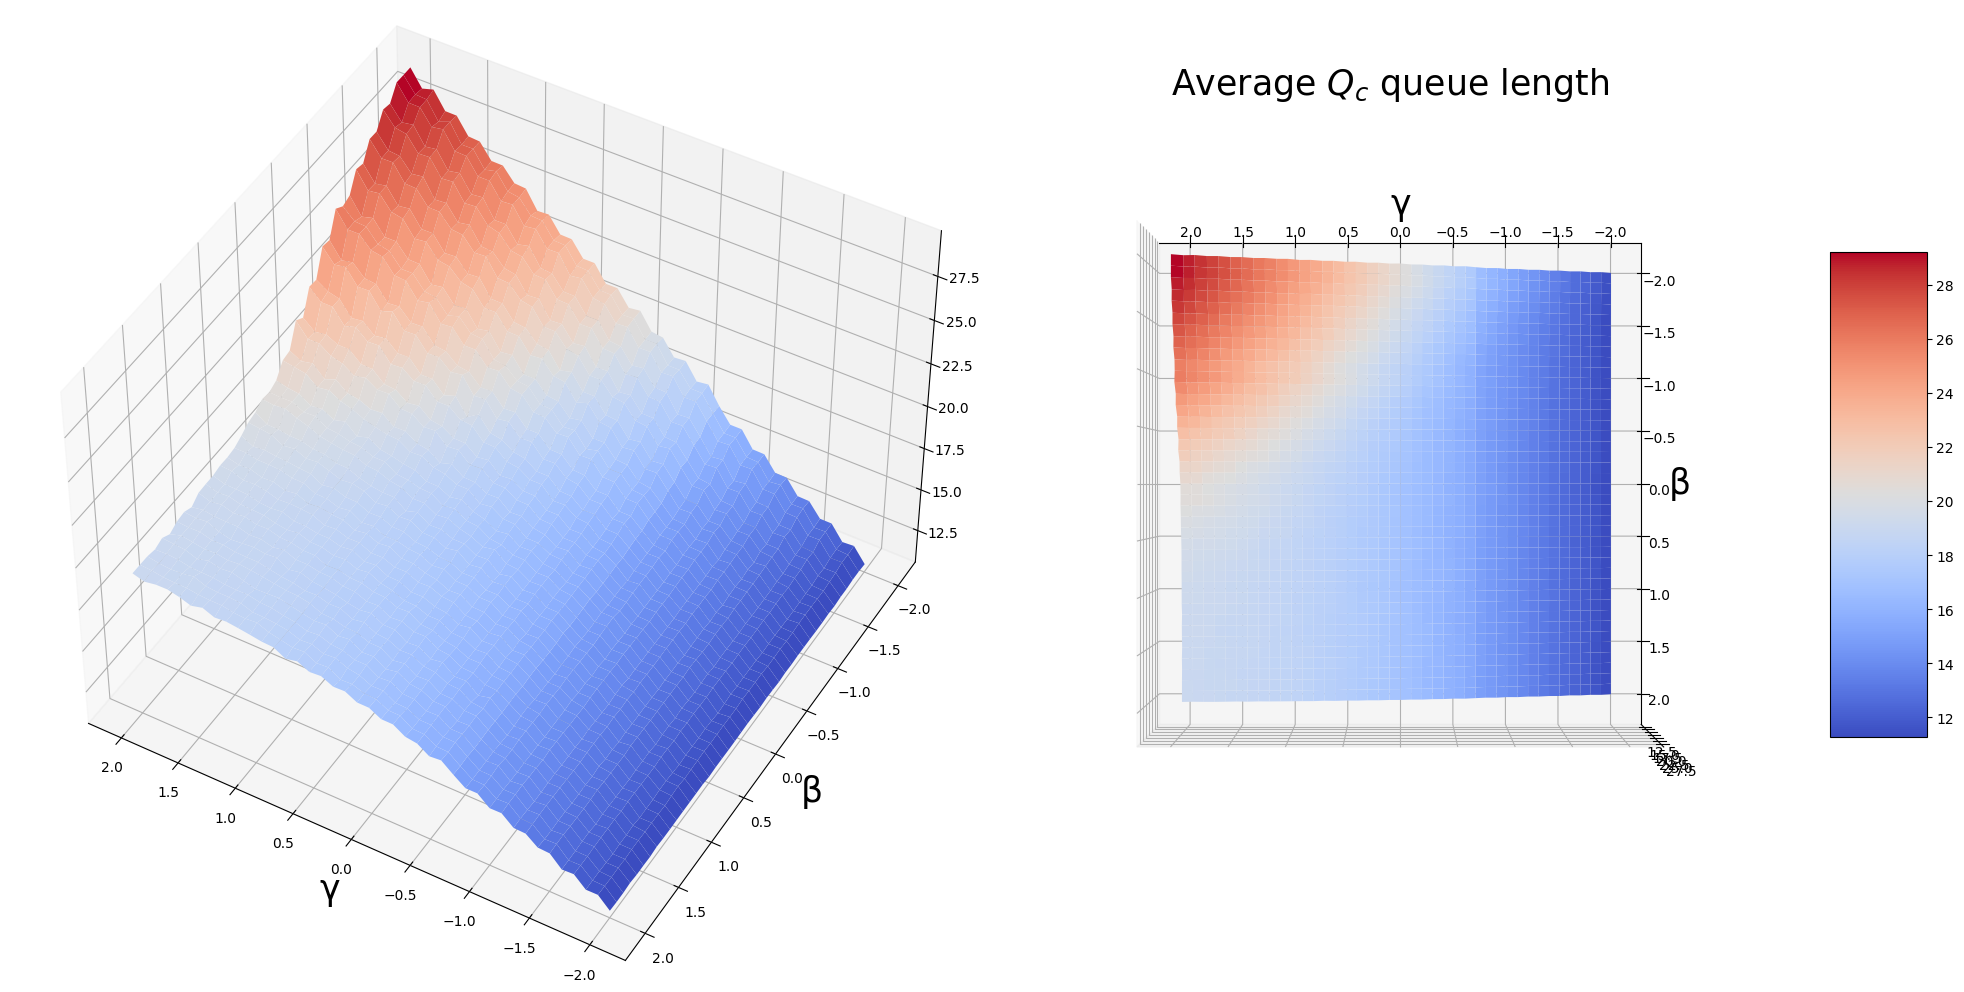

In [103]:
fig, ax = plt.subplots(1, 2, subplot_kw={"projection": "3d"})
plt.title("Average $Q_c$ queue length",fontsize=25)
fig.set_figheight(10)
fig.set_figwidth(20)
X, Y = np.meshgrid(γ_range, β_range)
ax[0].view_init(elev=45, azim=120)
ax[1].view_init(elev=90, azim=90)
ax[0].set_xlabel("γ", fontsize=25)
ax[0].set_ylabel("β", fontsize=25)
ax[1].set_xlabel("γ", fontsize=25)
ax[1].set_ylabel("β", fontsize=25)
surf = ax[0].plot_surface(X, Y, avg_Qc, cmap=plt.cm.coolwarm)
surf = ax[1].plot_surface(X, Y, avg_Qc, cmap=plt.cm.coolwarm)
fig.colorbar(surf, shrink=0.5, aspect=5)
fig.tight_layout()
plt.show()

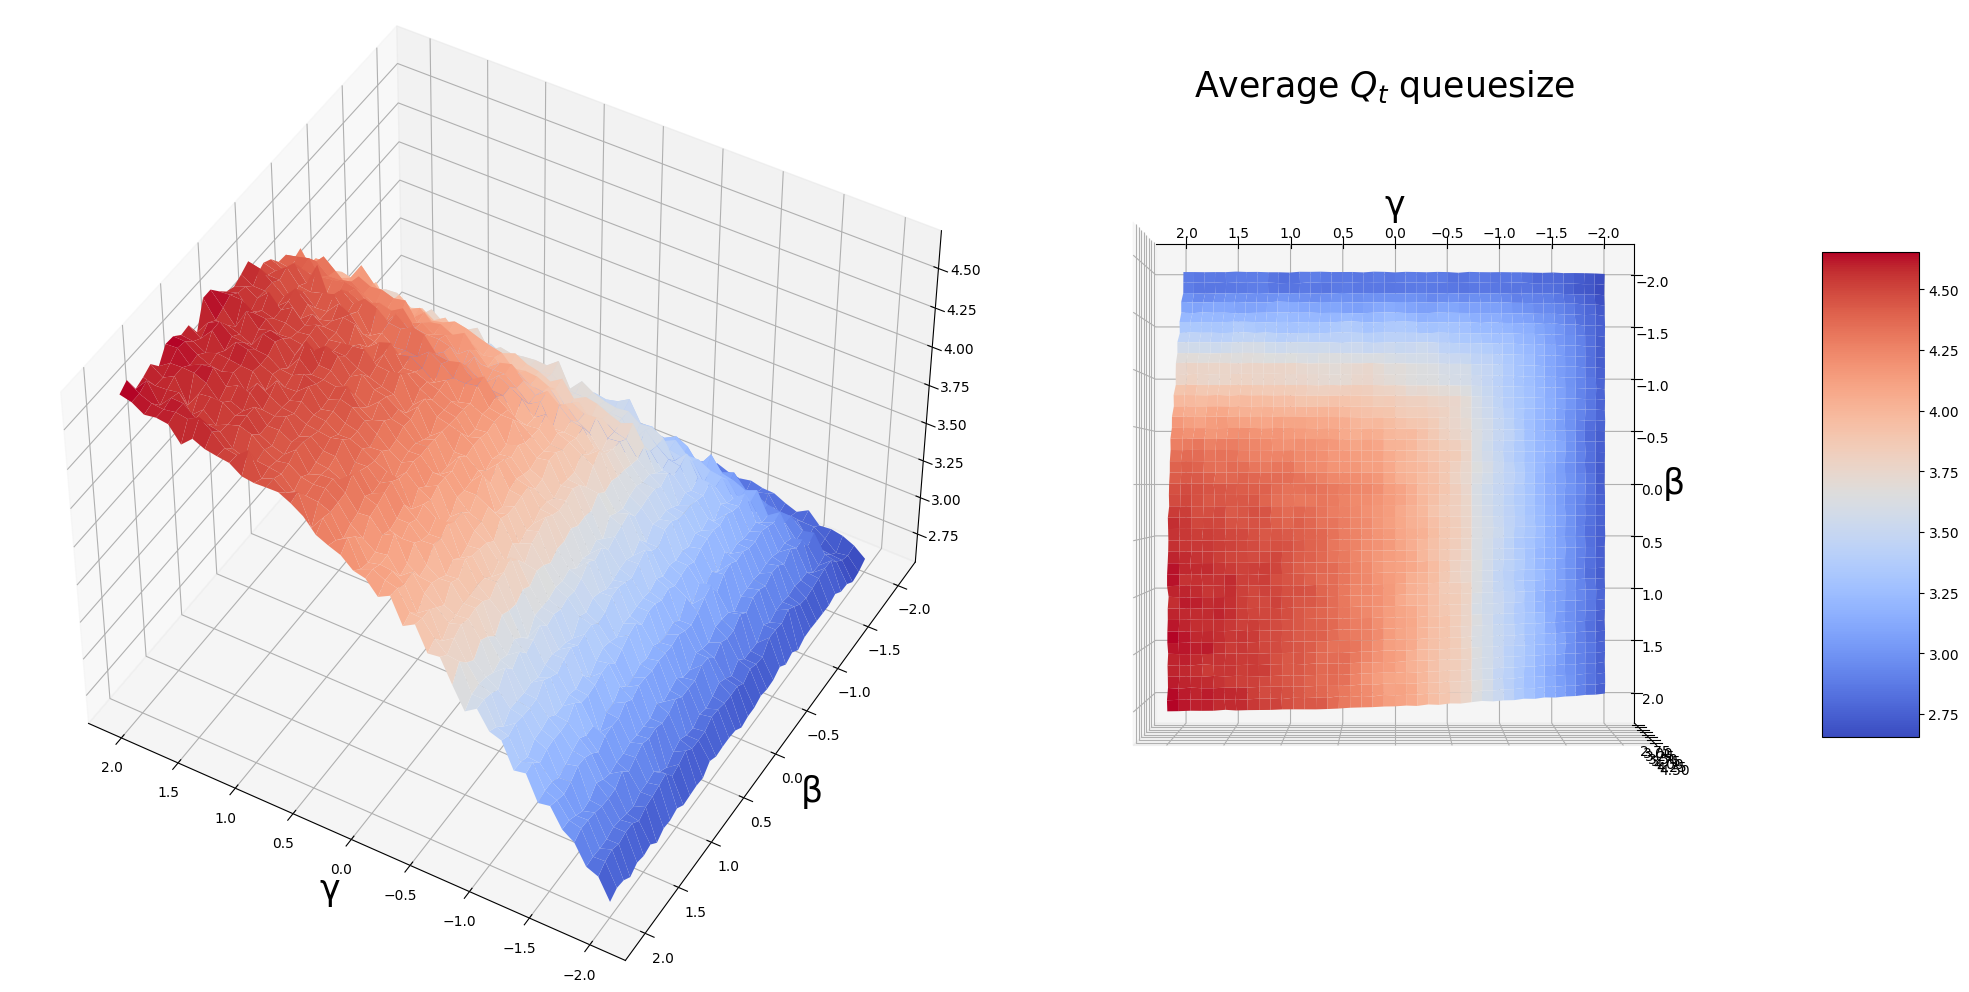

In [ ]:
fig, ax = plt.subplots(1, 2, subplot_kw={"projection": "3d"})
plt.title("Average $Q_t$ queue length",fontsize=25)
fig.set_figheight(10)
fig.set_figwidth(20)
X, Y = np.meshgrid(γ_range, β_range)
ax[0].view_init(elev=45, azim=120)
ax[1].view_init(elev=90, azim=90)
ax[0].set_xlabel("γ", fontsize=25)
ax[0].set_ylabel("β", fontsize=25)
ax[1].set_xlabel("γ", fontsize=25)
ax[1].set_ylabel("β", fontsize=25)
surf = ax[0].plot_surface(X, Y, avg_Qt, cmap=plt.cm.coolwarm)
surf = ax[1].plot_surface(X, Y, avg_Qt, cmap=plt.cm.coolwarm)
fig.colorbar(surf, shrink=0.5, aspect=5)
fig.tight_layout()
plt.show()

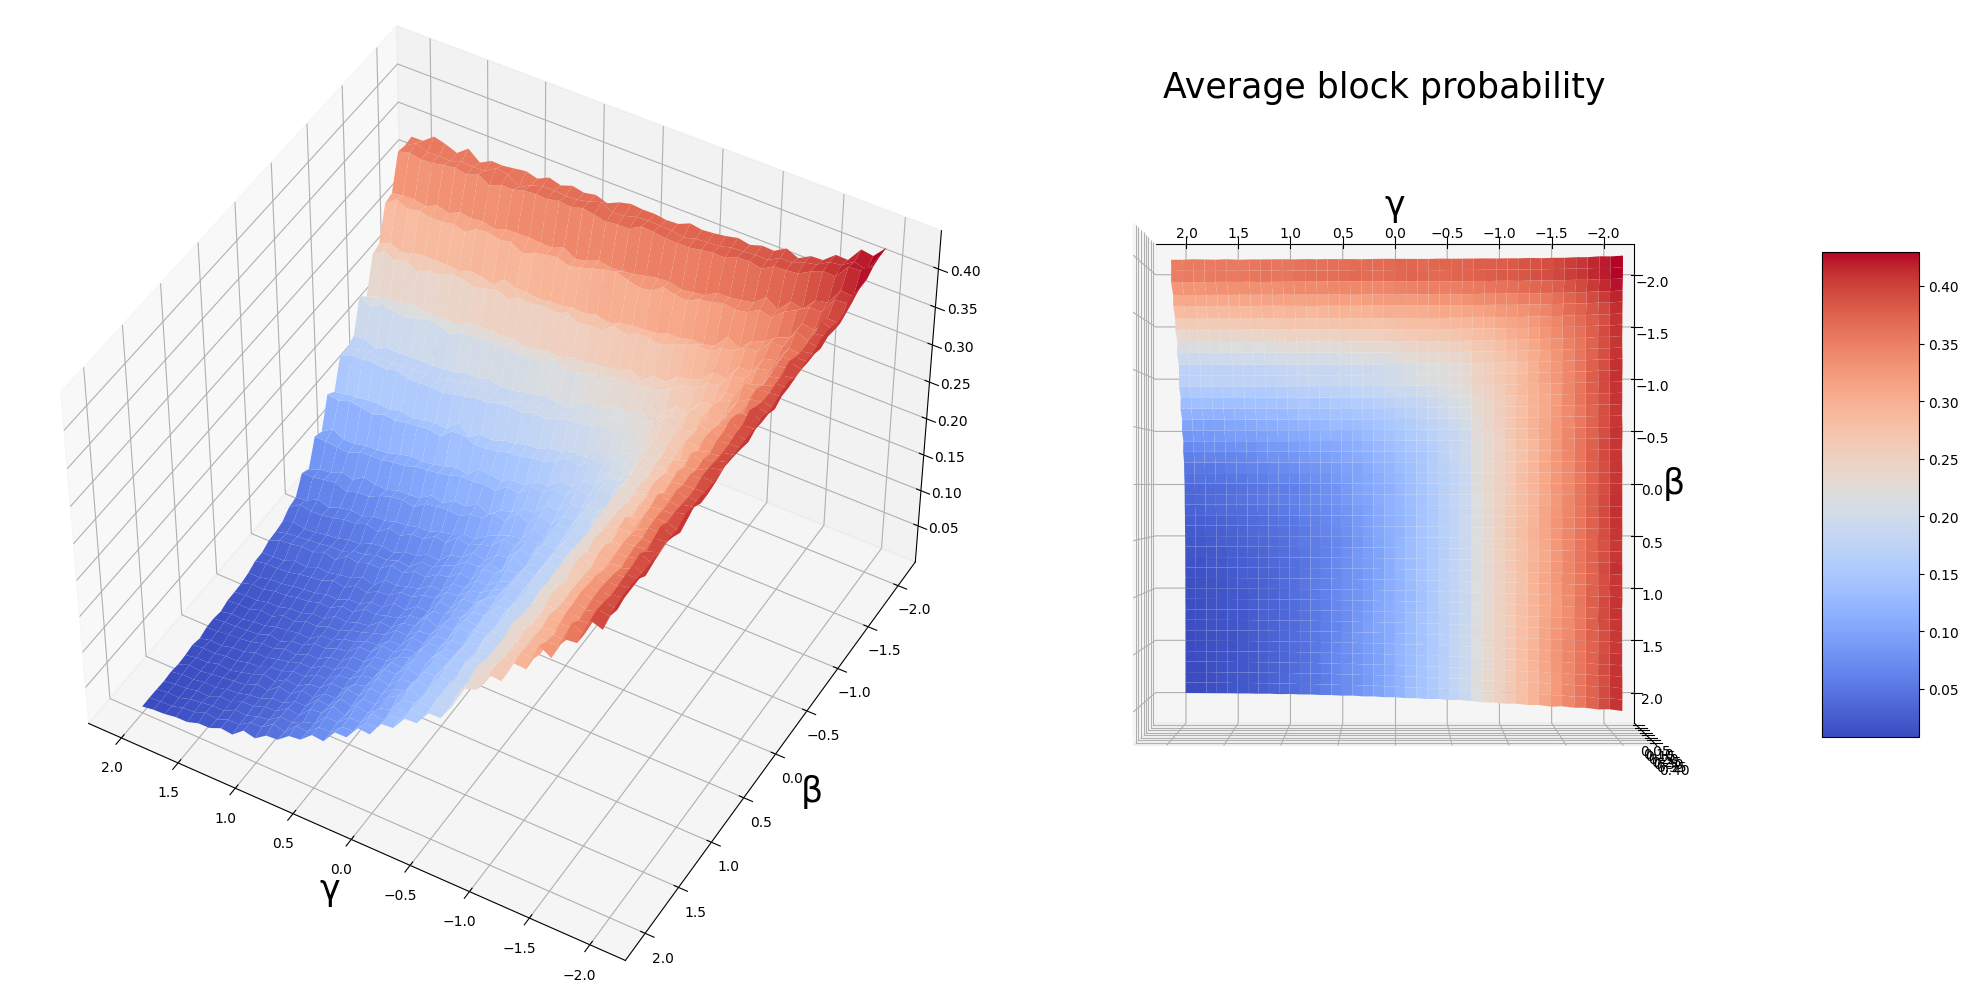

In [105]:
fig, ax = plt.subplots(1, 2, subplot_kw={"projection": "3d"})
plt.title("Average block probability",fontsize=25)
fig.set_figheight(10)
fig.set_figwidth(20)
X, Y = np.meshgrid(γ_range, β_range)
ax[0].view_init(elev=45, azim=120)
ax[1].view_init(elev=90, azim=90)
ax[0].set_xlabel("γ", fontsize=25)
ax[0].set_ylabel("β", fontsize=25)
ax[1].set_xlabel("γ", fontsize=25)
ax[1].set_ylabel("β", fontsize=25)
surf = ax[0].plot_surface(X, Y, block_prob, cmap=plt.cm.coolwarm)
surf = ax[1].plot_surface(X, Y, block_prob, cmap=plt.cm.coolwarm)
fig.colorbar(surf, shrink=0.5, aspect=5)
fig.tight_layout()
plt.show()

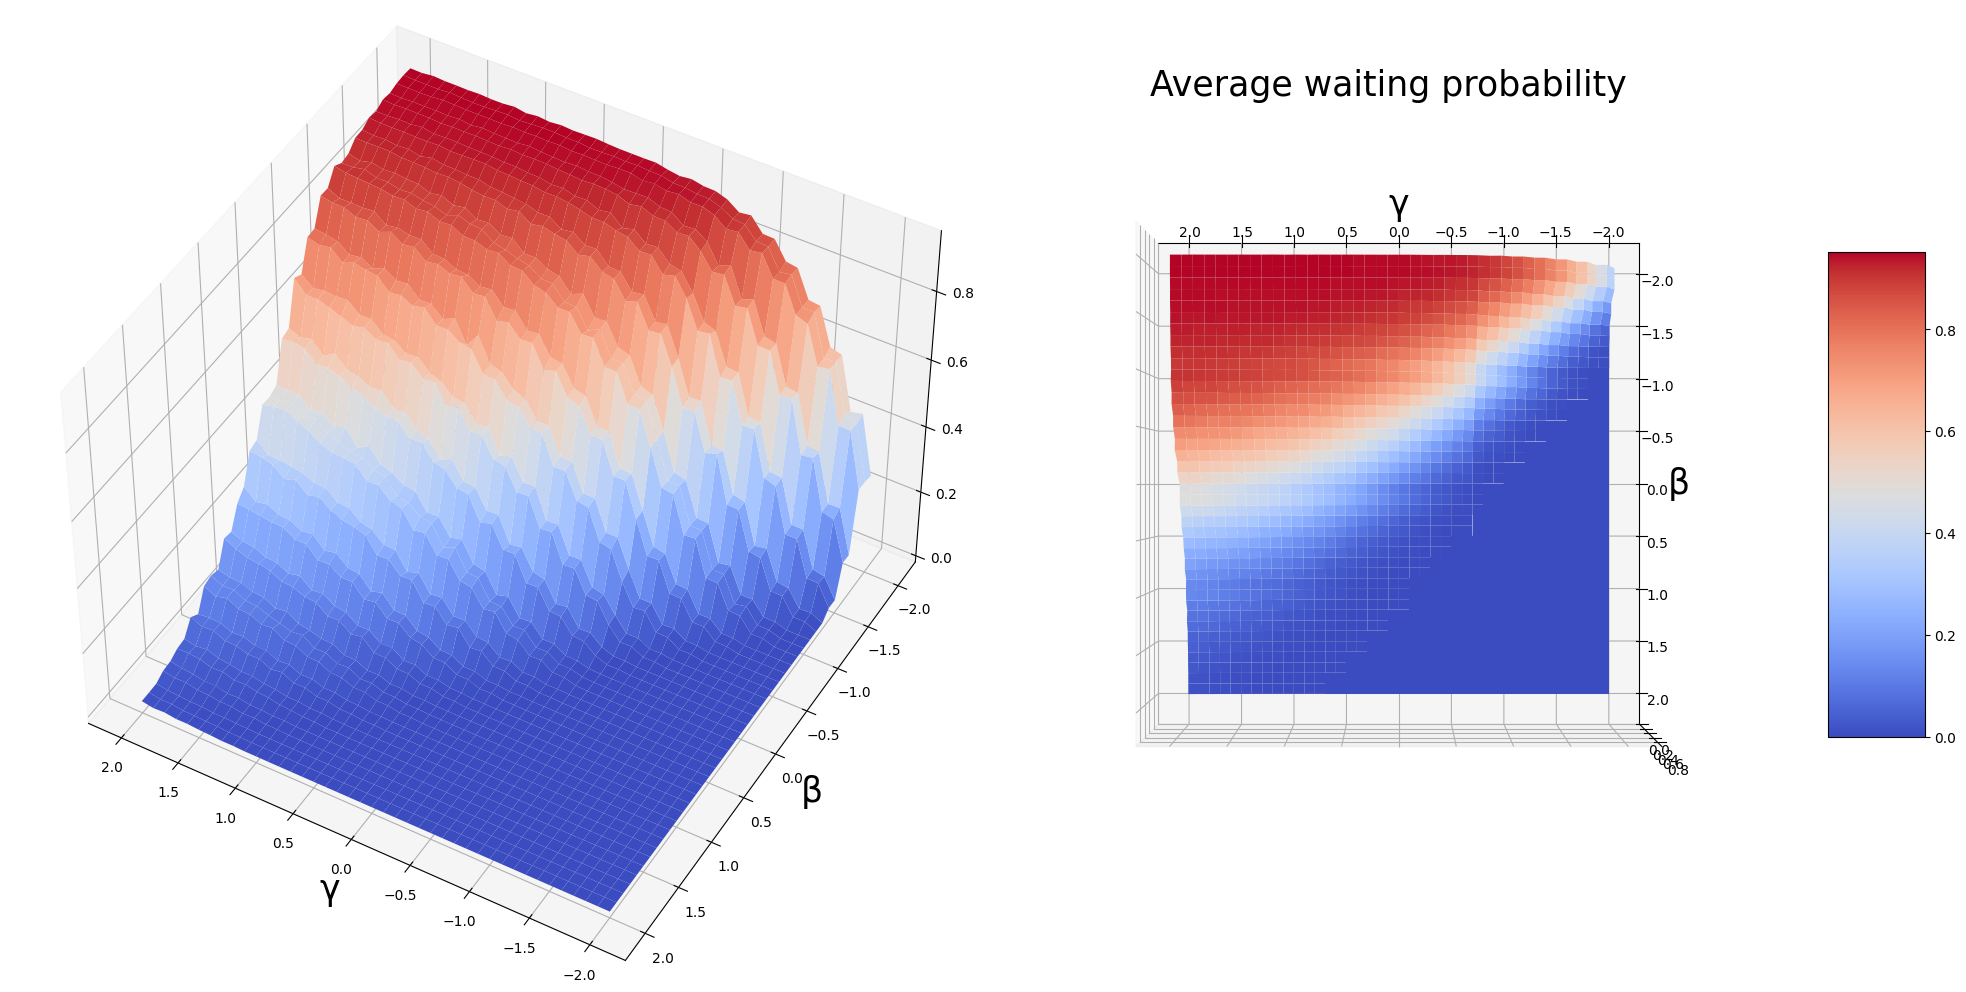

In [106]:
fig, ax = plt.subplots(1, 2, subplot_kw={"projection": "3d"})
plt.title("Average waiting probability",fontsize=25)
fig.set_figheight(10)
fig.set_figwidth(20)
X, Y = np.meshgrid(γ_range, β_range)
ax[0].view_init(elev=45, azim=120)
ax[1].view_init(elev=90, azim=90)
ax[0].set_xlabel("γ", fontsize=25)
ax[0].set_ylabel("β", fontsize=25)
ax[1].set_xlabel("γ", fontsize=25)
ax[1].set_ylabel("β", fontsize=25)
surf = ax[0].plot_surface(X, Y, waiting_prob, cmap=plt.cm.coolwarm)
surf = ax[1].plot_surface(X, Y, waiting_prob, cmap=plt.cm.coolwarm)
fig.colorbar(surf, shrink=0.5, aspect=5)
fig.tight_layout()
plt.show()

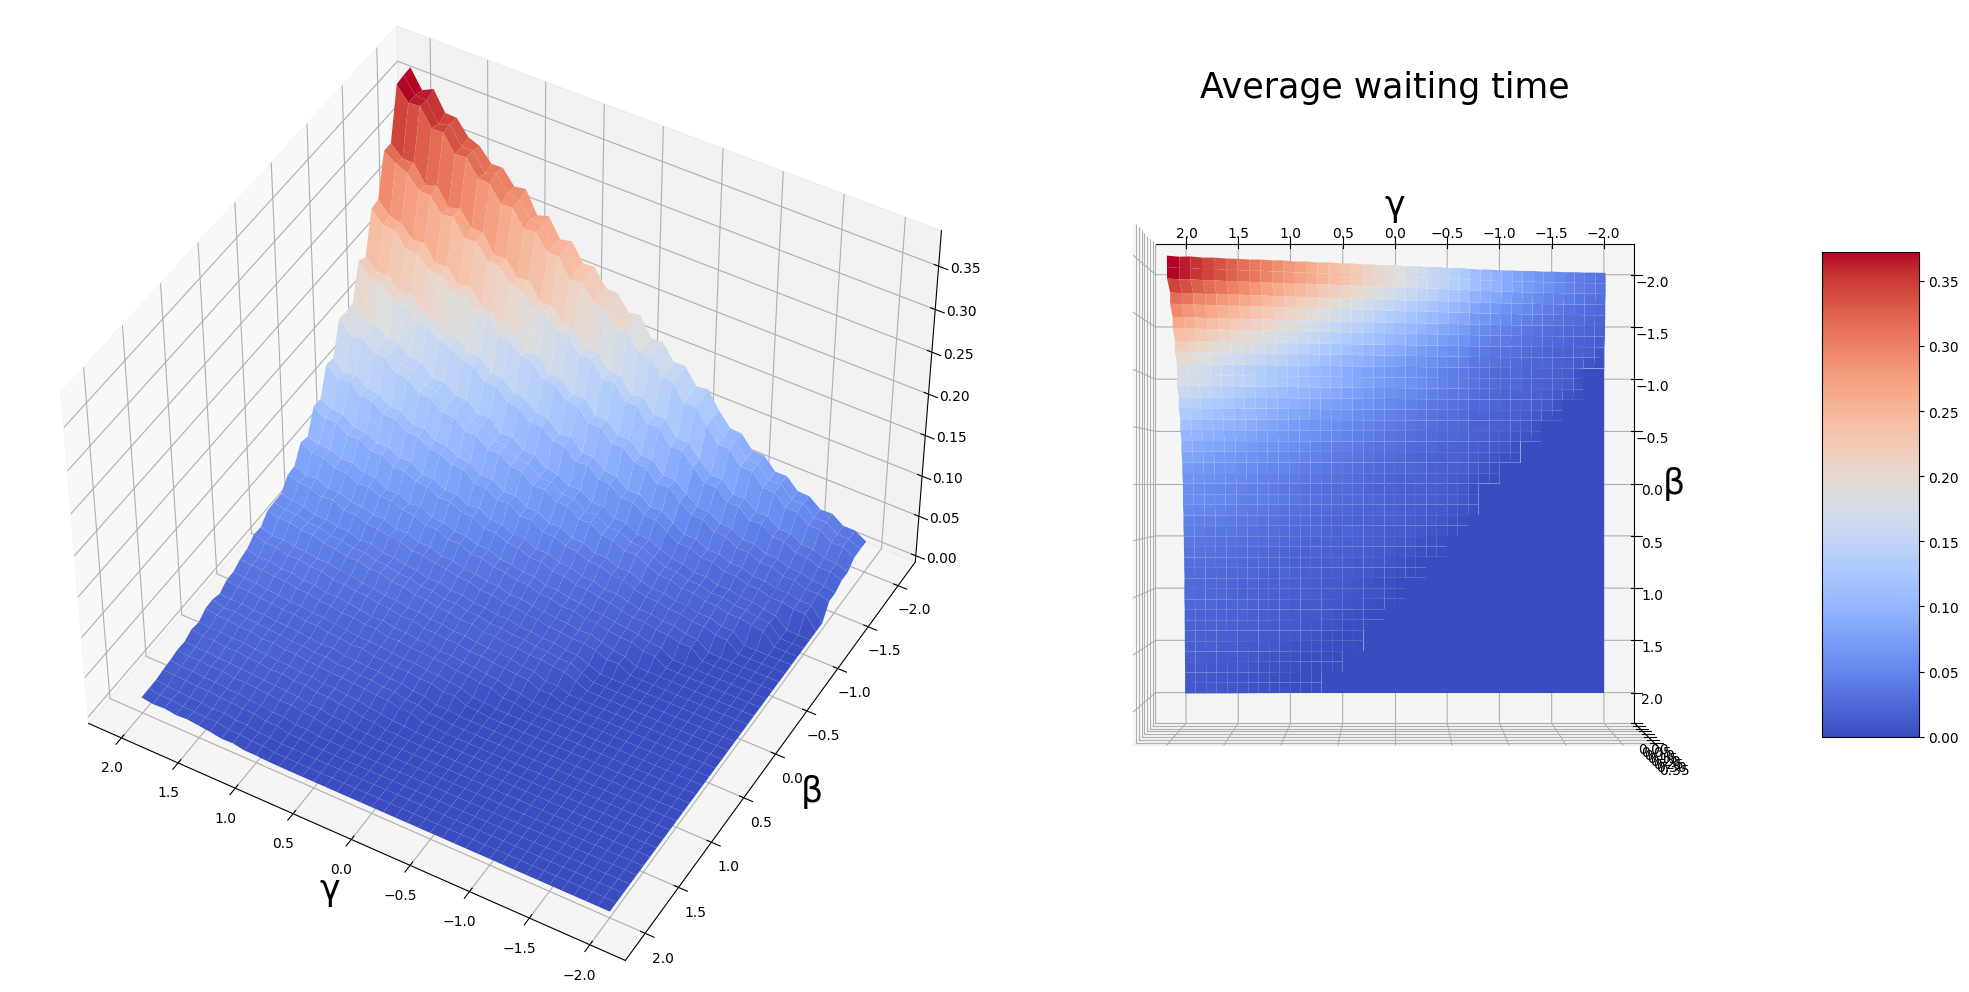

In [ ]:
fig, ax = plt.subplots(1, 2, subplot_kw={"projection": "3d"})
plt.title("Average waiting time",fontsize=25)
fig.set_figheight(10)
fig.set_figwidth(20)
X, Y = np.meshgrid(γ_range, β_range)
ax[0].view_init(elev=45, azim=120)
ax[1].view_init(elev=90, azim=90)
ax[0].set_xlabel("γ", fontsize=25)
ax[0].set_ylabel("β", fontsize=25)
ax[1].set_xlabel("γ", fontsize=25)
ax[1].set_ylabel("β", fontsize=25)
surf = ax[0].plot_surface(X, Y, avg_waiting_time, cmap=plt.cm.coolwarm)
surf = ax[1].plot_surface(X, Y, avg_waiting_time, cmap=plt.cm.coolwarm)
fig.colorbar(surf, shrink=0.5, aspect=5)
fig.tight_layout()
plt.show()